# 약물 수요 예측 프로젝트 - Step 5: 하이퍼파라미터 튜닝
**목표**: Walk-forward CV + Optuna로 XGBoost / LightGBM 최적화  
**베이스라인 (수정 후)**: XGBoost 전체 MAPE 23.43% / A10A 38.45% / A10B 8.41%

## 0. 환경 설정

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score
import xgboost as xgb
import lightgbm as lgb
import optuna
import warnings, os

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

RANDOM_STATE = 42
OUT_DATA = 'output/data'
OUT_FIG  = 'output/figures'
os.makedirs(OUT_FIG, exist_ok=True)

print('환경 설정 완료')
print(f'  XGBoost  버전: {xgb.__version__}')
print(f'  LightGBM 버전: {lgb.__version__}')
print(f'  Optuna   버전: {optuna.__version__}')

환경 설정 완료
  XGBoost  버전: 3.2.0
  LightGBM 버전: 4.6.0
  Optuna   버전: 4.8.0


## 1. 데이터 로드 및 Feature 준비

In [2]:
df = pd.read_csv(f'{OUT_DATA}/merged_master.csv', encoding='utf-8-sig')
df['기간_dt'] = pd.to_datetime(df['기간_dt'])
df = df.sort_values(['약물구분', '시군구명칭', '기간_dt']).reset_index(drop=True)

def make_features(df):
    df = df.copy()
    group = ['약물구분', '시군구명칭']
    for lag in [1, 2, 3]:
        df[f'lag_{lag}'] = df.groupby(group)['수량'].shift(lag)
    shifted = df.groupby(group)['수량'].shift(1)
    df['rolling_mean_3'] = shifted.groupby(
        [df['약물구분'], df['시군구명칭']]
    ).transform(lambda x: x.rolling(3).mean())
    df['rolling_std_3'] = shifted.groupby(
        [df['약물구분'], df['시군구명칭']]
    ).transform(lambda x: x.rolling(3).std())
    # 전월 대비 증감률 (lag_1→lag_2 기준, 데이터 누수 없음)
    df['lag1_pct_change'] = (df['lag_1'] - df['lag_2']) / (df['lag_2'] + 1)
    df['month_sin'] = np.sin(2 * np.pi * df['월'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['월'] / 12)
    le = LabelEncoder()
    df['gu_encoded']   = le.fit_transform(df['시군구명칭'])
    df['drug_encoded'] = (df['약물구분'] == 'A10B').astype(int)
    return df, le

df_feat, le_gu = make_features(df)
df_feat = df_feat.dropna(
    subset=['lag_1', 'lag_2', 'lag_3', 'rolling_mean_3']
).reset_index(drop=True)

FEATURE_COLS = [
    'lag_1', 'lag_2', 'lag_3',
    'rolling_mean_3', 'rolling_std_3', 'lag1_pct_change',
    'month_sin', 'month_cos', '연도', '월',
    '총거주자수', '세대당인구', '남여비율', '고령인구비율',
    'gu_encoded', 'drug_encoded'
]
TARGET     = '수량'
TRAIN_END  = '2025-04'
TEST_START = '2025-05'

train = df_feat[df_feat['기간_dt'] <= TRAIN_END]
test  = df_feat[df_feat['기간_dt'] >= TEST_START]
X_train, y_train = train[FEATURE_COLS], train[TARGET]
X_test,  y_test  = test[FEATURE_COLS],  test[TARGET]

print(f'Train: {train["기간_dt"].min().strftime("%Y-%m")} ~ {train["기간_dt"].max().strftime("%Y-%m")}  ({len(train):,}행)')
print(f'Test : {test["기간_dt"].min().strftime("%Y-%m")} ~ {test["기간_dt"].max().strftime("%Y-%m")}  ({len(test):,}행)')
print(f'Feature 수: {len(FEATURE_COLS)}')

Train: 2024-01 ~ 2025-04  (800행)
Test : 2025-05 ~ 2025-10  (300행)
Feature 수: 16


## 2. Walk-forward CV 설계

| Fold | Train | Validation |
|---|---|---|
| 1 | 2024-01 ~ 2024-07 | 2024-08 ~ 2024-10 |
| 2 | 2024-01 ~ 2024-10 | 2024-11 ~ 2025-01 |
| 3 | 2024-01 ~ 2025-01 | 2025-02 ~ 2025-04 |

확장 윈도우(expanding window) — 검증 구간을 미래로 점진적으로 이동

In [3]:
# (train_end, val_start, val_end) — 3개월 검증 윈도우, 확장 훈련
WF_FOLDS = [
    ('2024-07', '2024-08', '2024-10'),
    ('2024-10', '2024-11', '2025-01'),
    ('2025-01', '2025-02', '2025-04'),
]

def mape_score(y_true, y_pred):
    mask = y_true > 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def walk_forward_cv(model_fn, folds=WF_FOLDS):
    scores = []
    for train_end, val_start, val_end in folds:
        tr  = df_feat[df_feat['기간_dt'] <= train_end]
        val = df_feat[(df_feat['기간_dt'] >= val_start) & (df_feat['기간_dt'] <= val_end)]
        model = model_fn()
        model.fit(tr[FEATURE_COLS], tr[TARGET])
        pred  = np.clip(model.predict(val[FEATURE_COLS]), 0, None)
        scores.append(mape_score(val[TARGET].values, pred))
    return np.mean(scores), scores

print('Walk-forward CV 설계 완료')
for i, (te, vs, ve) in enumerate(WF_FOLDS, 1):
    tr_n  = len(df_feat[df_feat['기간_dt'] <= te])
    val_n = len(df_feat[(df_feat['기간_dt'] >= vs) & (df_feat['기간_dt'] <= ve)])
    print(f'  Fold {i}: Train ~{te} ({tr_n}행)  →  Val {vs}~{ve} ({val_n}행)')

Walk-forward CV 설계 완료
  Fold 1: Train ~2024-07 (350행)  →  Val 2024-08~2024-10 (150행)
  Fold 2: Train ~2024-10 (500행)  →  Val 2024-11~2025-01 (150행)
  Fold 3: Train ~2025-01 (650행)  →  Val 2025-02~2025-04 (150행)


## 3. 베이스라인 Walk-forward CV 성능

In [4]:
baseline_fns = {
    'Linear Reg': lambda: LinearRegression(),
    'XGBoost (기본)': lambda: xgb.XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        random_state=RANDOM_STATE, verbosity=0),
    'LightGBM (기본)': lambda: lgb.LGBMRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=5, num_leaves=31,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        random_state=RANDOM_STATE, verbosity=-1),
}

print('=== 베이스라인 Walk-forward CV MAPE ===')
baseline_cv_scores = {}
for name, fn in baseline_fns.items():
    mean_m, fold_m = walk_forward_cv(fn)
    baseline_cv_scores[name] = mean_m
    fold_str = '  /  '.join(f'Fold{i+1}: {v:.2f}%' for i, v in enumerate(fold_m))
    print(f'  {name:20s}  평균={mean_m:6.2f}%  [{fold_str}]')

=== 베이스라인 Walk-forward CV MAPE ===
  Linear Reg            평균=1169.78%  [Fold1: 2803.32%  /  Fold2: 417.71%  /  Fold3: 288.32%]
  XGBoost (기본)          평균= 16.12%  [Fold1: 16.07%  /  Fold2: 15.71%  /  Fold3: 16.58%]
  LightGBM (기본)         평균= 99.81%  [Fold1: 178.28%  /  Fold2: 38.43%  /  Fold3: 82.72%]


## 4. Optuna — XGBoost 하이퍼파라미터 튜닝 (100 trials)

In [5]:
def objective_xgb(trial):
    params = dict(
        n_estimators     = trial.suggest_int('n_estimators', 100, 800),
        learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        max_depth        = trial.suggest_int('max_depth', 3, 8),
        subsample        = trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.6, 1.0),
        reg_alpha        = trial.suggest_float('reg_alpha', 0.0, 2.0),
        reg_lambda       = trial.suggest_float('reg_lambda', 0.5, 5.0),
        min_child_weight = trial.suggest_int('min_child_weight', 1, 10),
        random_state=RANDOM_STATE, verbosity=0,
    )
    mean_mape, _ = walk_forward_cv(lambda: xgb.XGBRegressor(**params))
    return mean_mape

study_xgb = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
study_xgb.optimize(objective_xgb, n_trials=100, show_progress_bar=True)

print(f'\nXGBoost 최적 CV MAPE: {study_xgb.best_value:.2f}%  (베이스라인: {baseline_cv_scores["XGBoost (기본)"]:.2f}%)')
print('최적 파라미터:')
for k, v in study_xgb.best_params.items():
    print(f'  {k:20s}: {v}')

  0%|          | 0/100 [00:00<?, ?it/s]


XGBoost 최적 CV MAPE: 12.34%  (베이스라인: 16.12%)
최적 파라미터:
  n_estimators        : 476
  learning_rate       : 0.03201011255711805
  max_depth           : 8
  subsample           : 0.9815420250324431
  colsample_bytree    : 0.6575052244119917
  reg_alpha           : 1.9566167380820072
  reg_lambda          : 1.4228351680405003
  min_child_weight    : 1


## 5. Optuna — LightGBM 하이퍼파라미터 튜닝 (100 trials)

In [6]:
def objective_lgb(trial):
    params = dict(
        n_estimators      = trial.suggest_int('n_estimators', 100, 800),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        max_depth         = trial.suggest_int('max_depth', 3, 8),
        num_leaves        = trial.suggest_int('num_leaves', 15, 127),
        subsample         = trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.6, 1.0),
        reg_alpha         = trial.suggest_float('reg_alpha', 0.0, 2.0),
        reg_lambda        = trial.suggest_float('reg_lambda', 0.5, 5.0),
        min_child_samples = trial.suggest_int('min_child_samples', 5, 50),
        random_state=RANDOM_STATE, verbosity=-1,
    )
    mean_mape, _ = walk_forward_cv(lambda: lgb.LGBMRegressor(**params))
    return mean_mape

study_lgb = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
study_lgb.optimize(objective_lgb, n_trials=100, show_progress_bar=True)

print(f'\nLightGBM 최적 CV MAPE: {study_lgb.best_value:.2f}%  (베이스라인: {baseline_cv_scores["LightGBM (기본)"]:.2f}%)')
print('최적 파라미터:')
for k, v in study_lgb.best_params.items():
    print(f'  {k:20s}: {v}')

  0%|          | 0/100 [00:00<?, ?it/s]


LightGBM 최적 CV MAPE: 24.66%  (베이스라인: 99.81%)
최적 파라미터:
  n_estimators        : 734
  learning_rate       : 0.16665991068764094
  max_depth           : 8
  num_leaves          : 53
  subsample           : 0.7111025659345424
  colsample_bytree    : 0.6903652279389412
  reg_alpha           : 1.1700243979972706
  reg_lambda          : 0.931179612242123
  min_child_samples   : 5


## 6. 최종 테스트셋 평가 (튜닝 전 vs 후)

In [7]:
# 튜닝된 모델 — 전체 train으로 최종 학습
best_xgb = xgb.XGBRegressor(**study_xgb.best_params, random_state=RANDOM_STATE, verbosity=0)
best_lgb = lgb.LGBMRegressor(**study_lgb.best_params, random_state=RANDOM_STATE, verbosity=-1)
best_xgb.fit(X_train, y_train)
best_lgb.fit(X_train, y_train)
pred_xgb_tuned = np.clip(best_xgb.predict(X_test), 0, None)
pred_lgb_tuned = np.clip(best_lgb.predict(X_test), 0, None)

# 베이스라인 모델 재학습
base_xgb = xgb.XGBRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=5,
    subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
    random_state=RANDOM_STATE, verbosity=0)
base_lgb = lgb.LGBMRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=5, num_leaves=31,
    subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
    random_state=RANDOM_STATE, verbosity=-1)
base_xgb.fit(X_train, y_train)
base_lgb.fit(X_train, y_train)
pred_xgb_base = np.clip(base_xgb.predict(X_test), 0, None)
pred_lgb_base = np.clip(base_lgb.predict(X_test), 0, None)

def eval_all(y_true, y_pred, drug_col):
    rows = []
    for scope in ['전체', 'A10A', 'A10B']:
        if scope == '전체':
            yt, yp = y_true.values, y_pred
        else:
            mask = drug_col == scope
            yt, yp = y_true[mask].values, y_pred[mask]
        rows.append({
            '범위': scope,
            'MAE':  np.mean(np.abs(yt - yp)),
            'RMSE': np.sqrt(np.mean((yt - yp)**2)),
            'MAPE': mape_score(yt, yp),
            'R²':   r2_score(yt, yp),
        })
    return pd.DataFrame(rows).set_index('범위')

xgb_base_df  = eval_all(y_test, pred_xgb_base,  test['약물구분'])
xgb_tuned_df = eval_all(y_test, pred_xgb_tuned, test['약물구분'])
lgb_base_df  = eval_all(y_test, pred_lgb_base,  test['약물구분'])
lgb_tuned_df = eval_all(y_test, pred_lgb_tuned, test['약물구분'])

print('=== XGBoost: 베이스라인 vs 튜닝 ===')
print('[베이스라인]')
display(xgb_base_df.style.format({'MAE':'{:,.0f}','RMSE':'{:,.0f}','MAPE':'{:.2f}%','R²':'{:.4f}'}))
print('[튜닝 후]')
display(xgb_tuned_df.style.format({'MAE':'{:,.0f}','RMSE':'{:,.0f}','MAPE':'{:.2f}%','R²':'{:.4f}'}))

print('\n=== LightGBM: 베이스라인 vs 튜닝 ===')
print('[베이스라인]')
display(lgb_base_df.style.format({'MAE':'{:,.0f}','RMSE':'{:,.0f}','MAPE':'{:.2f}%','R²':'{:.4f}'}))
print('[튜닝 후]')
display(lgb_tuned_df.style.format({'MAE':'{:,.0f}','RMSE':'{:,.0f}','MAPE':'{:.2f}%','R²':'{:.4f}'}))

=== XGBoost: 베이스라인 vs 튜닝 ===
[베이스라인]


,MAE,RMSE,MAPE,R²
범위,,,,
전체,"96,657","175,125",23.43%,0.9824
A10A,"2,871","3,771",38.45%,0.8653
A10B,"190,443","247,635",8.41%,0.9276


[튜닝 후]


,MAE,RMSE,MAPE,R²
범위,,,,
전체,"93,656","173,671",12.08%,0.9827
A10A,"1,836","2,607",16.12%,0.9356
A10B,"185,476","245,594",8.04%,0.9288



=== LightGBM: 베이스라인 vs 튜닝 ===
[베이스라인]


,MAE,RMSE,MAPE,R²
범위,,,,
전체,"100,253","176,079",37.47%,0.9822
A10A,"6,269","8,904",66.16%,0.2489
A10B,"194,236","248,854",8.79%,0.9269


[튜닝 후]


,MAE,RMSE,MAPE,R²
범위,,,,
전체,"96,628","170,204",25.47%,0.9834
A10A,"3,458","5,008",42.55%,0.7624
A10B,"189,797","240,652",8.38%,0.9316


## 7. 성능 비교 시각화 (기본 vs 튜닝)

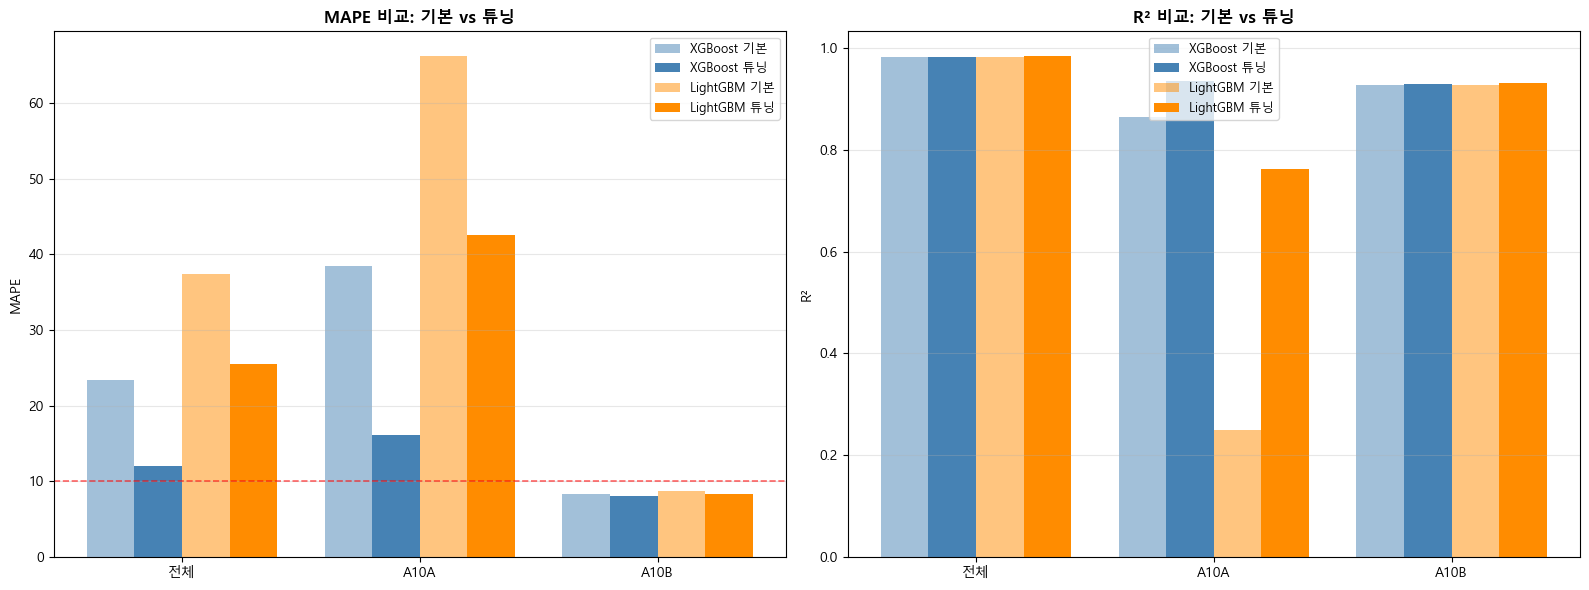

저장: output/figures/19_tuning_comparison.png


In [8]:
scopes = ['전체', 'A10A', 'A10B']
x      = np.arange(len(scopes))
width  = 0.2

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, metric in zip(axes, ['MAPE', 'R²']):
    xgb_base_vals  = [xgb_base_df.loc[s, metric]  for s in scopes]
    xgb_tuned_vals = [xgb_tuned_df.loc[s, metric] for s in scopes]
    lgb_base_vals  = [lgb_base_df.loc[s, metric]  for s in scopes]
    lgb_tuned_vals = [lgb_tuned_df.loc[s, metric] for s in scopes]

    ax.bar(x - 1.5*width, xgb_base_vals,  width, label='XGBoost 기본',  color='steelblue',  alpha=0.5)
    ax.bar(x - 0.5*width, xgb_tuned_vals, width, label='XGBoost 튜닝',  color='steelblue',  alpha=1.0)
    ax.bar(x + 0.5*width, lgb_base_vals,  width, label='LightGBM 기본', color='darkorange', alpha=0.5)
    ax.bar(x + 1.5*width, lgb_tuned_vals, width, label='LightGBM 튜닝', color='darkorange', alpha=1.0)

    ax.set_title(f'{metric} 비교: 기본 vs 튜닝', fontsize=12, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(scopes)
    ax.set_ylabel(metric)
    ax.legend(fontsize=9)
    ax.grid(True, axis='y', alpha=0.3)
    if metric == 'MAPE':
        ax.axhline(10, color='red', linestyle='--', linewidth=1.2, alpha=0.6, label='10% 기준')

plt.tight_layout()
path = f'{OUT_FIG}/19_tuning_comparison.png'
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f'저장: {path}')

## 8. Optuna 최적화 히스토리

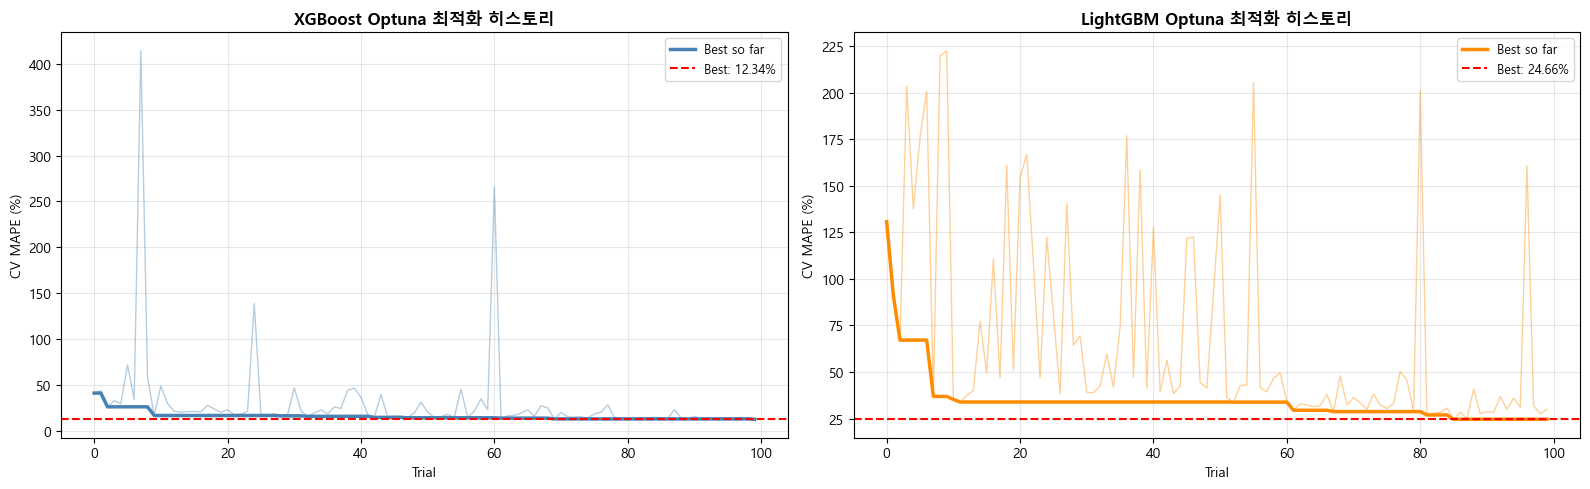

저장: output/figures/20_optuna_history.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, study, name, color in zip(
    axes,
    [study_xgb, study_lgb],
    ['XGBoost', 'LightGBM'],
    ['steelblue', 'darkorange']
):
    trials_df = study.trials_dataframe()
    ax.plot(trials_df.index, trials_df['value'], color=color, alpha=0.4, linewidth=1)
    best_so_far = trials_df['value'].cummin()
    ax.plot(trials_df.index, best_so_far, color=color, linewidth=2.5, label='Best so far')
    ax.axhline(study.best_value, color='red', linestyle='--', linewidth=1.5,
               label=f'Best: {study.best_value:.2f}%')
    ax.set_title(f'{name} Optuna 최적화 히스토리', fontsize=12, fontweight='bold')
    ax.set_xlabel('Trial')
    ax.set_ylabel('CV MAPE (%)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
path = f'{OUT_FIG}/20_optuna_history.png'
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f'저장: {path}')

## 9. Feature Importance (튜닝 후)

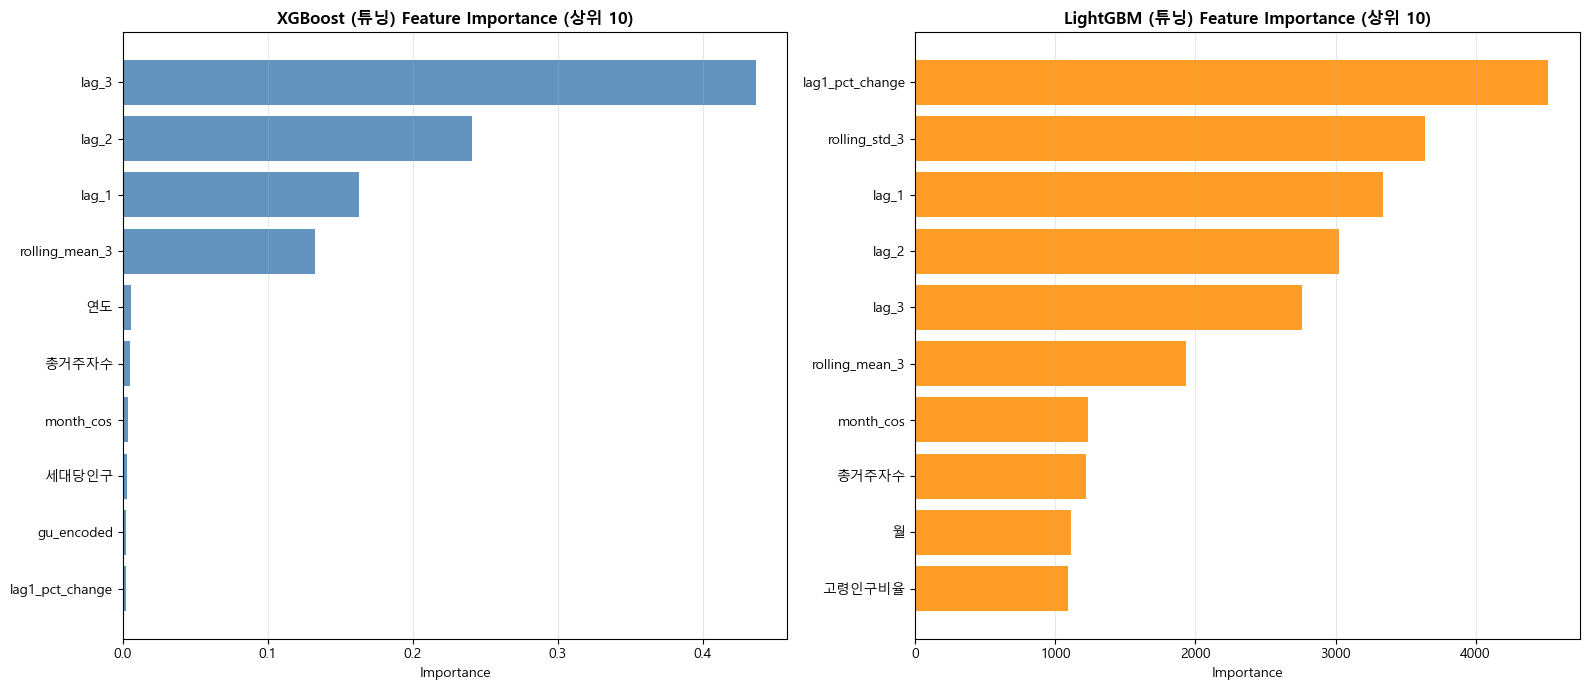

저장: output/figures/21_tuned_feature_importance.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, model, name, color in zip(
    axes,
    [best_xgb, best_lgb],
    ['XGBoost (튜닝)', 'LightGBM (튜닝)'],
    ['steelblue', 'darkorange']
):
    fi = pd.DataFrame({
        'feature': FEATURE_COLS,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False).head(10)
    ax.barh(fi['feature'][::-1], fi['importance'][::-1], color=color, alpha=0.85)
    ax.set_title(f'{name} Feature Importance (상위 10)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance')
    ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
path = f'{OUT_FIG}/21_tuned_feature_importance.png'
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f'저장: {path}')

## 10. 결과 저장

In [11]:
import json as _json

# 최적 파라미터 저장
best_params = {
    'xgboost':  study_xgb.best_params,
    'lightgbm': study_lgb.best_params,
}
with open(f'{OUT_DATA}/best_params.json', 'w', encoding='utf-8') as f:
    _json.dump(best_params, f, ensure_ascii=False, indent=2)

# 튜닝 전후 성능 요약 저장
rows = []
for model_name, base_df, tuned_df in [
    ('XGBoost',  xgb_base_df,  xgb_tuned_df),
    ('LightGBM', lgb_base_df,  lgb_tuned_df),
]:
    for scope in ['전체', 'A10A', 'A10B']:
        for tag, df_ in [('기본', base_df), ('튜닝', tuned_df)]:
            rows.append({
                '모델': model_name, '구분': tag, '범위': scope,
                'MAE':  df_.loc[scope, 'MAE'],
                'RMSE': df_.loc[scope, 'RMSE'],
                'MAPE': df_.loc[scope, 'MAPE'],
                'R2':   df_.loc[scope, 'R²'],
            })

df_tuning_summary = pd.DataFrame(rows)
df_tuning_summary.to_csv(f'{OUT_DATA}/tuning_summary.csv', index=False, encoding='utf-8-sig')

print('저장 완료:')
print(f'  {OUT_DATA}/best_params.json')
print(f'  {OUT_DATA}/tuning_summary.csv')
print()
print('=== 최종 성능 요약 (MAPE) ===')
pivot = df_tuning_summary.pivot_table(
    index=['모델','구분'], columns='범위', values='MAPE'
).round(2)
pivot.columns.name = 'MAPE(%)'
display(pivot.style.format('{:.2f}%').set_caption('모델 × 구분 × 범위별 MAPE'))

best_row = df_tuning_summary[df_tuning_summary['범위']=='전체'].sort_values('MAPE').iloc[0]
print(f'\n최우수: {best_row["모델"]} ({best_row["구분"]})  전체 MAPE {best_row["MAPE"]:.2f}%')

저장 완료:
  output/data/best_params.json
  output/data/tuning_summary.csv

=== 최종 성능 요약 (MAPE) ===



최우수: XGBoost (튜닝)  전체 MAPE 12.08%
